## Bayesian XG Model 
### by Adam Sequeira 
- put arviz paper here

#### Problem Statement 
In football there is a varying scale of richness of tagging data, if paying for third party systems, you can get or generate at a minimum basic (x,y) co-ordinates. From this you have the ability to generate a baseline xG model, by calculating shot_distance and shot_angle. 

One step further would be data that includes features associated with shots, including what body_part was used, was the player under_pressure, the shot technique, the play_pattern (free_kick, penalty etc...), this was standard in statsbomb's open dataset 

One step further than that, has been the release of statsbomb including freeze-frame data as part of their events, this include the x,y position of players off the ball along with other features like the assist_type and assist_height. 

While richer datasets generally produce more accurate xG estimates, the inverse is also true: when fewer features are available, there is greater uncertainty regarding the true probability of a goal. Traditional xG models, commonly implemented using logistic regression or machine learning classifiers, typically return a single point estimate for each shot. Although useful, these point estimates do not communicate how certain the model is about its prediction.

This creates a challenge when comparing xG values generated from different data providers, competitions, or historical datasets that contain varying levels of information. Two shots may receive the same predicted xG value despite one being estimated from rich contextual data and the other from only basic location data. Intuitively, confidence in these estimates should differ.

Bayesian modeling provides a natural framework for addressing this problem. Rather than producing a single probability estimate, Bayesian models generate a posterior distribution over the goal probability. This distribution quantifies both the estimated probability of scoring and the uncertainty surrounding that estimate. When informative features are unavailable, posterior distributions can widen to reflect increased uncertainty. Conversely, when richer contextual information is available, the posterior distribution can become more concentrated, indicating greater confidence in the prediction.

#### Why is this Relevant? 
The ability to quantify uncertainty is valuable for both practitioners and researchers. In football analytics, model outputs are often used to evaluate player/match shot quality. In recruitment, players go through different systems with different levels of richness in their data. 

A probabilistic framework also allows analysts to:

Distinguish between aleatoric uncertainty (inherent randomness in goal scoring) and epistemic uncertainty (uncertainty arising from limited information).
Compare xG estimates across datasets with different levels of feature richness.
Incorporate uncertainty directly into downstream models and decision-making processes.
Produce more robust estimates in situations with sparse data or rare events.


#### Goal 
- Generate one size fits all bayesian xg model that provides the following
    - posterior distribution of outcomes instead of standard point estimates 
    - able to factor in error for different tagging systems. 

In [11]:
import nutpie
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, brier_score_loss
from pathlib import Path

## Proposed Bayesian Model

Let each shot $i \in \{1, \ldots, N\}$ have observed goal outcome:

$$
y_i \sim \mathrm{Bernoulli}(p_i)
$$

with latent conversion probability (sigmoid) function:

$$
p_i = \sigma(\eta_i), \qquad \sigma(x) = \frac{1}{1 + e^{-x}}.
$$

### Data Analysis 
- Analyse feature selection for being able to select prior distributions 
- Many distributions came from arviz --> BayesXG article 

#### Model Builder 
Below is a form of model builder used in pymc, including relevant transformations,
continuous values are scaled using standard scaler.  

In [12]:
import nutpie
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, brier_score_loss
from pathlib import Path


def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))


class BayesianXg:
    """
    Bayesian expected goals model.

    Sampling options
    ----------------
    method="nuts"   : standard PyMC NUTS
    method="advi"   : variational inference
    method="nutpie" : nutpie NUTS sampler
    """

    version = "0.2"

    MODEL_VARIABLES = {
        "cont_cols": [
            "shot_angle",
            "shot_distance",
            "shot_distance_angle",
            "goalkeeper_shooter_distance",
            "goalkeeper_shooter_angle",
            "goalkeeper_shooter_distance_angle",
            "players_between_shooter_and_goal",
        ],
        "bin_cols": [
            "shot_first_time",
            "shot_follows_dribble",
            "under_pressure",
            "is_open_goal",
        ],
        "cat_cols": [
            "shot_body_part",
            "shot_technique",
            "assist_type",
            "assist_height",
            "play_pattern",
        ],
        "pressure_col": "defensive_pressure",
    }

    def __init__(
        self,
        df: pd.DataFrame = None,
        target_col: str = None,
        method: str = "nutpie",
        **sample_kwargs,
    ):
        self.idata = None
        self.approx = None
        self._scaler = None
        self._cat_categories = None
        self._pressure_levels = None

        self.method = method
        self.target_col = target_col if target_col else None
        self._model_inputs = (
            self._preprocess(df, target_col, fit_scaler=True)
            if df is not None and target_col is not None
            else None
        )
        self.model = self._build_model(model_inputs=self._model_inputs) if self._model_inputs is not None else None

    # =========================================================
    # PUBLIC API
    # =========================================================

    def fit(self, df: pd.DataFrame = None, target_col: str = None, method: str = None, **sample_kwargs):
        if method is None:
            method = self.method

        if self._model_inputs is None:
            self._model_inputs = self._preprocess(df, target_col, fit_scaler=True)
            self.model = self._build_model(model_inputs=self._model_inputs)

        if method == "advi":
            self.idata, self.approx = self._sample_advi(self.model, **sample_kwargs)
        elif method == "nutpie":
            self.idata = self._sample_nutpie(self.model, **sample_kwargs)
        elif method == "nuts":
            self.idata = self._sample_nuts(self.model, **sample_kwargs)
        else:
            raise ValueError(f"Unknown method '{method}'. Choose 'nuts', 'advi', or 'nutpie'.")

        return self

    def predict(self, df: pd.DataFrame, target_col: str = None):
        if self.idata is None:
            raise RuntimeError("Call fit() before predict().")

        if target_col is None:
            target_col = self.target_col

        xg_mean, xg_std = self._posterior_mean_xg(df, target_col, self.idata.posterior)
        return xg_mean, xg_std

    def evaluate(
        self,
        df: pd.DataFrame,
        target_col: str,
        use_posterior_predict_sampling: bool = False,
        n_samples: int = 1000,
    ):
        if use_posterior_predict_sampling:
            ppc = self._posterior_predict_sampling(df, target_col=target_col, n_samples=n_samples)

            if hasattr(ppc, "posterior_predictive"):
                p_samples = np.asarray(ppc.posterior_predictive["p"].values)
            elif isinstance(ppc, dict):
                p_samples = np.asarray(ppc["p"])
            else:
                raise TypeError("Unsupported posterior predictive return type.")

            p_samples = p_samples.reshape(-1, p_samples.shape[-1])
            if n_samples is not None and p_samples.shape[0] > n_samples:
                p_samples = p_samples[:n_samples]

            xg_mean = p_samples.mean(axis=0)
            xg_std = p_samples.std(axis=0)
        else:
            xg_mean, xg_std = self.predict(df, target_col=target_col)

        y_true = df[target_col].fillna(0).astype(int).to_numpy()
        return {
            "roc_auc": roc_auc_score(y_true, xg_mean),
            "brier": brier_score_loss(y_true, xg_mean),
            "xg_mean": xg_mean,
            "xg_std": xg_std,
        }

    def save_trace(self, path: str):
        if self.idata is None:
            raise RuntimeError("Nothing to save - call fit() first.")
        p = Path(path)
        p.parent.mkdir(parents=True, exist_ok=True)
        self.idata.to_netcdf(str(p))
        print(f"Trace saved -> {p}")

    def load_trace(self, path: str):
        self.idata = az.from_netcdf(path)
        print(f"Trace loaded <- {path}")
        return self

    # =========================================================
    # SAMPLERS
    # =========================================================

    def _sample_nuts(self, model, draws=1000, tune=1000, chains=4, target_accept=0.9, **kwargs):
        with model:
            idata = pm.sample(
                draws=draws,
                tune=tune,
                chains=chains,
                target_accept=target_accept,
                progressbar=True,
                **kwargs,
            )
        return idata

    def _sample_advi(self, model, n=50_000, draws=2000, **kwargs):
        with model:
            approx = pm.fit(n=n, method="advi", progressbar=True, **kwargs)
            idata = approx.sample(draws)
        return idata, approx

    def _sample_nutpie(self, model, draws=1000, tune=1000, chains=4, **kwargs):
        compiled = nutpie.compile_pymc_model(model)
        idata = nutpie.sample(compiled, draws=draws, tune=tune, chains=chains, **kwargs)
        return idata

    # =========================================================
    # MODEL DEFINITION
    # =========================================================

    def _build_model(self, model_inputs: dict = None):
        if model_inputs is None:
            model_inputs = self._model_inputs

        with pm.Model() as model:
            # ---------- data ----------
            shot_angle = pm.Data("shot_angle", np.asarray(model_inputs["shot_angle"]))
            shot_distance = pm.Data("shot_distance", np.asarray(model_inputs["shot_distance"]))
            shot_dist_ang = pm.Data("shot_distance_angle", np.asarray(model_inputs["shot_distance_angle"]))
            gk_dist = pm.Data("goalkeeper_shooter_distance", np.asarray(model_inputs["goalkeeper_shooter_distance"]))
            gk_angle = pm.Data("goalkeeper_shooter_angle", np.asarray(model_inputs["goalkeeper_shooter_angle"]))
            gk_dist_ang = pm.Data("goalkeeper_shooter_distance_angle", np.asarray(model_inputs["goalkeeper_shooter_distance_angle"]))
            players_bet = pm.Data("players_between", np.asarray(model_inputs["players_between_shooter_and_goal"]))

            shot_ft = pm.Data("shot_first_time", np.asarray(model_inputs["shot_first_time"]))
            shot_fd = pm.Data("shot_follows_dribble", np.asarray(model_inputs["shot_follows_dribble"]))
            under_p = pm.Data("under_pressure", np.asarray(model_inputs["under_pressure"]))
            open_g = pm.Data("is_open_goal", np.asarray(model_inputs["is_open_goal"]))

            m_shot_angle = pm.Data("shot_angle_missing", np.asarray(model_inputs["shot_angle_missing"]))
            m_shot_dist = pm.Data("shot_distance_missing", np.asarray(model_inputs["shot_distance_missing"]))
            m_shot_dist_ang = pm.Data("shot_distance_angle_missing", np.asarray(model_inputs["shot_distance_angle_missing"]))
            m_gk_dist = pm.Data("gk_dist_missing", np.asarray(model_inputs["goalkeeper_shooter_distance_missing"]))
            m_gk_angle = pm.Data("gk_angle_missing", np.asarray(model_inputs["goalkeeper_shooter_angle_missing"]))
            m_gk_dist_ang = pm.Data("gk_dist_angle_missing", np.asarray(model_inputs["goalkeeper_shooter_distance_angle_missing"]))
            m_players_bet = pm.Data("players_between_missing", np.asarray(model_inputs["players_between_shooter_and_goal_missing"]))

            m_shot_ft = pm.Data("shot_first_time_missing", np.asarray(model_inputs["shot_first_time_missing"]))
            m_shot_fd = pm.Data("shot_follows_dribble_missing", np.asarray(model_inputs["shot_follows_dribble_missing"]))
            m_under_p = pm.Data("under_pressure_missing", np.asarray(model_inputs["under_pressure_missing"]))
            m_open_g = pm.Data("is_open_goal_missing", np.asarray(model_inputs["is_open_goal_missing"]))
            # m_pressure_levels = pm.Data("pressure_levels_missing", np.asarray(model_inputs["pressure_levels_missing"]))

            sbp_idx = pm.Data("shot_body_part_idx", np.asarray(model_inputs["cat_idx"]["shot_body_part"]))
            st_idx = pm.Data("shot_technique_idx", np.asarray(model_inputs["cat_idx"]["shot_technique"]))
            at_idx = pm.Data("assist_type_idx", np.asarray(model_inputs["cat_idx"]["assist_type"]))
            ah_idx = pm.Data("assist_height_idx", np.asarray(model_inputs["cat_idx"]["assist_height"]))
            pp_idx = pm.Data("play_pattern_idx", np.asarray(model_inputs["cat_idx"]["play_pattern"]))
            dp_idx = pm.Data("pressure_idx", np.asarray(model_inputs["pressure_idx"]))


            m_sbp = pm.Data("shot_body_part_missing", np.asarray(model_inputs["shot_body_part_missing"]))
            m_st = pm.Data("shot_technique_missing", np.asarray(model_inputs["shot_technique_missing"]))
            m_at = pm.Data("assist_type_missing", np.asarray(model_inputs["assist_type_missing"]))
            m_ah = pm.Data("assist_height_missing", np.asarray(model_inputs["assist_height_missing"]))
            m_pp = pm.Data("play_pattern_missing", np.asarray(model_inputs["play_pattern_missing"]))
            m_dp = pm.Data("pressure_missing", np.asarray(model_inputs["pressure_missing"]))

            y = pm.Data("y", np.asarray(model_inputs["y"]))

            # ---------- priors ----------
            alpha = pm.Normal("alpha", mu=-2.2, sigma=1)

            b_shot_angle      = pm.SkewNormal("beta_shot_angle",          mu=0,    sigma=5, alpha=1)
            b_shot_dist       = pm.SkewNormal("beta_shot_distance",       mu=0,    sigma=5, alpha=-1)
            b_shot_dist_angle = pm.SkewNormal("beta_shot_distance_angle", mu=0.5,  sigma=1, alpha=4)
            b_gk_dist         = pm.SkewNormal("beta_gk_dist",             mu=0,    sigma=5, alpha=1)
            b_gk_angle        = pm.SkewNormal("beta_gk_angle",            mu=1,    sigma=1, alpha=4)
            b_gk_dist_angle   = pm.SkewNormal("beta_gk_dist_angle",       mu=-1,   sigma=1, alpha=-4)
            b_players_between         = pm.SkewNormal("beta_players_between",     mu=-1,   sigma=1.5, alpha=-6)

            b_shot_first_time  = pm.Normal("beta_shot_first_time",      mu=0, sigma=5)
            b_shot_follows_dribble  = pm.Normal("beta_shot_follows_dribble", mu=0, sigma=5)
            b_under_pressure  = pm.Normal("beta_under_pressure",       mu=0, sigma=5)
            b_is_open_goal  = pm.SkewNormal("beta_is_open_goal",     mu=0, sigma=5, alpha=4)


            # Missing-value latent terms (x_ik^mis)
            shot_angle_mis_lat = pm.StudentT("shot_angle_mis_lat", nu=3, mu=0, sigma=1)
            shot_dist_mis_lat = pm.StudentT("shot_dist_mis_lat", nu=3, mu=0, sigma=1)
            shot_dist_ang_mis_lat = pm.StudentT("shot_dist_ang_mis_lat", nu=3, mu=0, sigma=1)
            gk_dist_mis_lat = pm.StudentT("gk_dist_mis_lat", nu=3, mu=0, sigma=1)
            gk_angle_mis_lat = pm.StudentT("gk_angle_mis_lat", nu=3, mu=0, sigma=1)
            gk_dist_ang_mis_lat = pm.StudentT("gk_dist_ang_mis_lat", nu=3, mu=0, sigma=1)
            players_mis_lat = pm.StudentT("players_mis_lat", nu=3, mu=0, sigma=1)

            shot_ft_mis_lat = pm.Beta("shot_ft_mis_lat", 2, 2)
            shot_fd_mis_lat = pm.Beta("shot_fd_mis_lat", 2, 2)
            under_p_mis_lat = pm.Beta("under_p_mis_lat", 2, 2)
            open_g_mis_lat = pm.Beta("open_g_mis_lat", 2, 2)

            # Categorical embeddings (unknown level captures missing/unseen)
            sbp_emb = pm.Normal("shot_body_part_emb", 0, 1, shape=model_inputs["n_levels"]["shot_body_part"])
            st_emb = pm.Normal("shot_technique_emb", 0, 1, shape=model_inputs["n_levels"]["shot_technique"])
            at_emb = pm.Normal("assist_type_emb", 0, 1, shape=model_inputs["n_levels"]["assist_type"])
            ah_emb = pm.Normal("assist_height_emb", 0, 1, shape=model_inputs["n_levels"]["assist_height"])
            pp_emb = pm.Normal("play_pattern_emb", 0, 1, shape=model_inputs["n_levels"]["play_pattern"])
            b_pressure_levels = pm.Normal("beta_pressure_levels", 0, 1, shape=model_inputs["n_pressure_levels"])

            b_pressure_m = pm.Normal("beta_pressure_missing", 0, 1)
            sbp_mis_eff = pm.Normal("shot_body_part_missing_effect", 0, 1)
            st_mis_eff = pm.Normal("shot_technique_missing_effect", 0, 1)
            at_mis_eff = pm.Normal("assist_type_missing_effect", 0, 1)
            ah_mis_eff = pm.Normal("assist_height_missing_effect", 0, 1)
            pp_mis_eff = pm.Normal("play_pattern_missing_effect", 0, 1)

            # ---------- split equation: observed + missing ----------
            # eta_i = beta0 + sum_{k in O_i} beta_k x_obs + sum_{k in M_i} beta_k x_mis
            eta_obs = 0
            eta_mis = 0

            # continuous
            eta_obs += b_shot_angle * (shot_angle * (1 - m_shot_angle))
            eta_mis += b_shot_angle * (shot_angle_mis_lat * m_shot_angle)

            eta_obs += b_shot_dist * (shot_distance * (1 - m_shot_dist))
            eta_mis += b_shot_dist * (shot_dist_mis_lat * m_shot_dist)

            eta_obs += b_shot_dist_angle * (shot_dist_ang * (1 - m_shot_dist_ang))
            eta_mis += b_shot_dist_angle * (shot_dist_ang_mis_lat * m_shot_dist_ang)

            eta_obs += b_gk_dist * (gk_dist * (1 - m_gk_dist))
            eta_mis += b_gk_dist * (gk_dist_mis_lat * m_gk_dist)

            eta_obs += b_gk_angle * (gk_angle * (1 - m_gk_angle))
            eta_mis += b_gk_angle * (gk_angle_mis_lat * m_gk_angle)

            eta_obs += b_gk_dist_angle * (gk_dist_ang * (1 - m_gk_dist_ang))
            eta_mis += b_gk_dist_angle * (gk_dist_ang_mis_lat * m_gk_dist_ang)

            eta_obs += b_players_between * (players_bet * (1 - m_players_bet))
            eta_mis += b_players_between * (players_mis_lat * m_players_bet)

            # binary
            eta_obs += b_shot_first_time * (shot_ft * (1 - m_shot_ft))
            eta_mis += b_shot_first_time * (shot_ft_mis_lat * m_shot_ft)

            eta_obs += b_shot_follows_dribble * (shot_fd * (1 - m_shot_fd))
            eta_mis += b_shot_follows_dribble * (shot_fd_mis_lat * m_shot_fd)

            eta_obs += b_under_pressure * (under_p * (1 - m_under_p))
            eta_mis += b_under_pressure * (under_p_mis_lat * m_under_p)

            eta_obs += b_is_open_goal * (open_g * (1 - m_open_g))
            eta_mis += b_is_open_goal * (open_g_mis_lat * m_open_g)

            # pressure and categorical split terms
            eta_obs += b_pressure_levels[dp_idx] * (1 - m_dp)
            eta_mis += b_pressure_m * m_dp

            eta_obs += sbp_emb[sbp_idx] * (1 - m_sbp)
            eta_mis += sbp_mis_eff * m_sbp

            eta_obs += st_emb[st_idx] * (1 - m_st)
            eta_mis += st_mis_eff * m_st

            eta_obs += at_emb[at_idx] * (1 - m_at)
            eta_mis += at_mis_eff * m_at

            eta_obs += ah_emb[ah_idx] * (1 - m_ah)
            eta_mis += ah_mis_eff * m_ah

            eta_obs += pp_emb[pp_idx] * (1 - m_pp)
            eta_mis += pp_mis_eff * m_pp

            mu = alpha + eta_obs + eta_mis

            p = pm.Deterministic("p", pm.math.sigmoid(mu))
            pm.Bernoulli("y_obs", p=p, observed=y)

        return model

    def _posterior_predict_sampling(self, df: pd.DataFrame, target_col: str, n_samples: int = 1000):
        model_inputs = self._preprocess(df, target_col=target_col, fit_scaler=False)
        xg_model = self._build_model(model_inputs=model_inputs)

        with xg_model:
            pm.set_data({
                "shot_angle": np.asarray(model_inputs["shot_angle"]),
                "shot_distance": np.asarray(model_inputs["shot_distance"]),
                "shot_distance_angle": np.asarray(model_inputs["shot_distance_angle"]),
                "goalkeeper_shooter_distance": np.asarray(model_inputs["goalkeeper_shooter_distance"]),
                "goalkeeper_shooter_angle": np.asarray(model_inputs["goalkeeper_shooter_angle"]),
                "goalkeeper_shooter_distance_angle": np.asarray(model_inputs["goalkeeper_shooter_distance_angle"]),
                "players_between": np.asarray(model_inputs["players_between_shooter_and_goal"]),

                "shot_first_time": np.asarray(model_inputs["shot_first_time"]),
                "shot_follows_dribble": np.asarray(model_inputs["shot_follows_dribble"]),
                "under_pressure": np.asarray(model_inputs["under_pressure"]),
                "is_open_goal": np.asarray(model_inputs["is_open_goal"]),

                "shot_angle_missing": np.asarray(model_inputs["shot_angle_missing"]),
                "shot_distance_missing": np.asarray(model_inputs["shot_distance_missing"]),
                "shot_distance_angle_missing": np.asarray(model_inputs["shot_distance_angle_missing"]),
                "gk_dist_missing": np.asarray(model_inputs["goalkeeper_shooter_distance_missing"]),
                "gk_angle_missing": np.asarray(model_inputs["goalkeeper_shooter_angle_missing"]),
                "gk_dist_angle_missing": np.asarray(model_inputs["goalkeeper_shooter_distance_angle_missing"]),
                "players_between_missing": np.asarray(model_inputs["players_between_shooter_and_goal_missing"]),

                "shot_first_time_missing": np.asarray(model_inputs["shot_first_time_missing"]),
                "shot_follows_dribble_missing": np.asarray(model_inputs["shot_follows_dribble_missing"]),
                "under_pressure_missing": np.asarray(model_inputs["under_pressure_missing"]),
                "is_open_goal_missing": np.asarray(model_inputs["is_open_goal_missing"]),

                "shot_body_part_idx": np.asarray(model_inputs["cat_idx"]["shot_body_part"]),
                "shot_technique_idx": np.asarray(model_inputs["cat_idx"]["shot_technique"]),
                "assist_type_idx": np.asarray(model_inputs["cat_idx"]["assist_type"]),
                "assist_height_idx": np.asarray(model_inputs["cat_idx"]["assist_height"]),
                "play_pattern_idx": np.asarray(model_inputs["cat_idx"]["play_pattern"]),
                "pressure_idx": np.asarray(model_inputs["pressure_idx"]),
                "y": np.asarray(model_inputs["y"]),
            })

            ppc = pm.sample_posterior_predictive(
                self.idata,
                var_names=["y_obs", "p"],
                random_seed=42,
            )

        return ppc

    # =========================================================
    # POSTERIOR INFERENCE
    # =========================================================

    def _posterior_mean_xg(self, df: pd.DataFrame, target_col: str, posterior):
        def scalar(name):
            return np.asarray(posterior[name].values).reshape(-1)

        def emb(name):
            arr = np.asarray(posterior[name].values)
            return arr.reshape(-1, *arr.shape[2:])

        inputs = self._preprocess(df, target_col=target_col, fit_scaler=False)
        S = scalar("beta_shot_angle").shape[0]
        N = inputs["shot_angle"].shape[0]

        def b(arr):
            return arr.reshape(S, 1)

        def f(vec):
            return vec.reshape(1, N)

        mu = np.zeros((S, N), dtype=float)
        mu += b(scalar("alpha"))

        # Split equation term-by-term for observed and missing features
        mu += b(scalar("beta_shot_angle")) * f((1 - inputs["shot_angle_missing"]) * inputs["shot_angle"] + inputs["shot_angle_missing"] * scalar("xmis_shot_angle").mean())
        mu += b(scalar("beta_shot_distance")) * f((1 - inputs["shot_distance_missing"]) * inputs["shot_distance"] + inputs["shot_distance_missing"] * scalar("xmis_shot_distance").mean())
        mu += b(scalar("beta_shot_distance_angle")) * f((1 - inputs["shot_distance_angle_missing"]) * inputs["shot_distance_angle"] + inputs["shot_distance_angle_missing"] * scalar("xmis_shot_distance_angle").mean())
        mu += b(scalar("beta_gk_dist")) * f((1 - inputs["goalkeeper_shooter_distance_missing"]) * inputs["goalkeeper_shooter_distance"] + inputs["goalkeeper_shooter_distance_missing"] * scalar("xmis_gk_dist").mean())
        mu += b(scalar("beta_gk_angle")) * f((1 - inputs["goalkeeper_shooter_angle_missing"]) * inputs["goalkeeper_shooter_angle"] + inputs["goalkeeper_shooter_angle_missing"] * scalar("xmis_gk_angle").mean())
        mu += b(scalar("beta_gk_dist_angle")) * f((1 - inputs["goalkeeper_shooter_distance_angle_missing"]) * inputs["goalkeeper_shooter_distance_angle"] + inputs["goalkeeper_shooter_distance_angle_missing"] * scalar("xmis_gk_dist_angle").mean())
        mu += b(scalar("beta_players_between")) * f((1 - inputs["players_between_shooter_and_goal_missing"]) * inputs["players_between_shooter_and_goal"] + inputs["players_between_shooter_and_goal_missing"] * scalar("xmis_players_between").mean())

        mu += b(scalar("beta_shot_first_time")) * f((1 - inputs["shot_first_time_missing"]) * inputs["shot_first_time"] + inputs["shot_first_time_missing"] * scalar("xmis_shot_first_time").mean())
        mu += b(scalar("beta_shot_follows_dribble")) * f((1 - inputs["shot_follows_dribble_missing"]) * inputs["shot_follows_dribble"] + inputs["shot_follows_dribble_missing"] * scalar("xmis_shot_follows_dribble").mean())
        mu += b(scalar("beta_under_pressure")) * f((1 - inputs["under_pressure_missing"]) * inputs["under_pressure"] + inputs["under_pressure_missing"] * scalar("xmis_under_pressure").mean())
        mu += b(scalar("beta_is_open_goal")) * f((1 - inputs["is_open_goal_missing"]) * inputs["is_open_goal"] + inputs["is_open_goal_missing"] * scalar("xmis_is_open_goal").mean())

        # categorical / pressure (missing encoded as unknown category)
        mu += emb("shot_body_part_emb")[:, inputs["cat_idx"]["shot_body_part"]]
        mu += emb("shot_technique_emb")[:, inputs["cat_idx"]["shot_technique"]]
        mu += emb("assist_type_emb")[:, inputs["cat_idx"]["assist_type"]]
        mu += emb("assist_height_emb")[:, inputs["cat_idx"]["assist_height"]]
        mu += emb("play_pattern_emb")[:, inputs["cat_idx"]["play_pattern"]]
        mu += emb("beta_pressure_levels")[:, inputs["pressure_idx"]]

        p = sigmoid(mu)
        return p.mean(axis=0), p.std(axis=0)

    # =========================================================
    # PREPROCESSING
    # =========================================================

    def _preprocess(self, df: pd.DataFrame, target_col, fit_scaler: bool) -> dict:
        mv = self.MODEL_VARIABLES
        X = df.copy()

        if "shot_distance_angle" not in X.columns:
            X["shot_distance_angle"] = X["shot_angle"] * X["shot_distance"]
        if "goalkeeper_shooter_distance_angle" not in X.columns:
            X["goalkeeper_shooter_distance_angle"] = X["goalkeeper_shooter_angle"] * X["goalkeeper_shooter_distance"]

        for col in mv["cont_cols"] + mv["bin_cols"] + mv["cat_cols"] + [mv["pressure_col"]]:
            if col not in X.columns:
                X[col] = np.nan

        X_cont, X_cont_missing = self._transform_continuous(X, fit_scaler)
        X_bin, X_bin_missing = self._transform_binary(X)
        cat_idx, cat_missing, cat_categories, n_levels = self._transform_categorical(X, fit_scaler)
        pressure_idx, pressure_missing, n_pressure_levels, levels = self._transform_pressure(X, fit_scaler)

        model_inputs = {
            "shot_angle": X_cont[:, 0],
            "shot_angle_missing": X_cont_missing[:, 0],
            "shot_distance": X_cont[:, 1],
            "shot_distance_missing": X_cont_missing[:, 1],
            "shot_distance_angle": X_cont[:, 2],
            "shot_distance_angle_missing": X_cont_missing[:, 2],
            "goalkeeper_shooter_distance": X_cont[:, 3],
            "goalkeeper_shooter_distance_missing": X_cont_missing[:, 3],
            "goalkeeper_shooter_angle": X_cont[:, 4],
            "goalkeeper_shooter_angle_missing": X_cont_missing[:, 4],
            "goalkeeper_shooter_distance_angle": X_cont[:, 5],
            "goalkeeper_shooter_distance_angle_missing": X_cont_missing[:, 5],
            "players_between_shooter_and_goal": X_cont[:, 6],
            "players_between_shooter_and_goal_missing": X_cont_missing[:, 6],

            "shot_first_time": X_bin[:, 0],
            "shot_first_time_missing": X_bin_missing[:, 0],
            "shot_follows_dribble": X_bin[:, 1],
            "shot_follows_dribble_missing": X_bin_missing[:, 1],
            "under_pressure": X_bin[:, 2],
            "under_pressure_missing": X_bin_missing[:, 2],
            "is_open_goal": X_bin[:, 3],
            "is_open_goal_missing": X_bin_missing[:, 3],

            "pressure_idx": pressure_idx,
            "pressure_missing": pressure_missing,
            "pressure_levels": levels,
            "n_pressure_levels": n_pressure_levels,

            "cat_idx": cat_idx,
            "cat_missing": cat_missing,
            "cat_categories": cat_categories,
            "n_levels": n_levels,

            "shot_body_part_missing": cat_missing["shot_body_part"],
            "shot_technique_missing": cat_missing["shot_technique"],
            "assist_type_missing": cat_missing["assist_type"],
            "assist_height_missing": cat_missing["assist_height"],
            "play_pattern_missing": cat_missing["play_pattern"],
        }

        if target_col is not None:
            model_inputs["y"] = df[target_col].fillna(0).astype(int).to_numpy()
        else:
            model_inputs["y"] = np.zeros(len(df), dtype=int)

        return model_inputs

    def _transform_continuous(self, X: pd.DataFrame, fit_scaler: bool):
        cols = self.MODEL_VARIABLES["cont_cols"]
        missing = X[cols].isna().astype(float).to_numpy()

        if fit_scaler:
            self._scaler = StandardScaler()
            self._scaler.fit(X[cols])

        scaled = self._scaler.transform(X[cols])
        scaled = np.where(np.isnan(scaled), 0.0, scaled)
        return scaled, missing

    def _transform_binary(self, X: pd.DataFrame):
        cols = self.MODEL_VARIABLES["bin_cols"]
        missing = X[cols].isna().astype(float).to_numpy()

        Xb = (
            X[cols]
            .replace({
                "True": 1, "False": 0, "true": 1, "false": 0,
                "TRUE": 1, "FALSE": 0, True: 1, False: 0,
            })
            .apply(pd.to_numeric, errors="coerce")
            .fillna(-1.0)
            .to_numpy(dtype=float)
        )
        return Xb, missing

    def _transform_categorical(self, X: pd.DataFrame, fit_scaler: bool):
        cols = self.MODEL_VARIABLES["cat_cols"]
        cat_missing_df = X[cols].isna().astype(float)
        cat_idx = {}
        cat_missing = {}
        n_levels = {}
        cat_categories = {}

        for col in cols:
            if fit_scaler:
                known = [c for c in X[col].dropna().unique().tolist() if pd.notna(c)]
                self._cat_categories = self._cat_categories or {}
                self._cat_categories[col] = known
            else:
                self._cat_categories = self._cat_categories or {}
                known = self._cat_categories.get(col, [])
                if not isinstance(known, list):
                    known = list(known)

            cat = pd.Categorical(X[col], categories=known)
            codes = cat.codes.copy()
            unknown_idx = len(known)
            codes = np.where(codes == -1, unknown_idx, codes).astype(int)

            cat_idx[col] = codes
            cat_missing[col] = cat_missing_df[col].to_numpy()
            n_levels[col] = len(known) + 1
            cat_categories[col] = known + ["Unknown"]

        return cat_idx, cat_missing, cat_categories, n_levels

    def _transform_pressure(self, X: pd.DataFrame, fit_scaler: bool):
        col = self.MODEL_VARIABLES["pressure_col"]
        series = X[col]
        missing = series.isna().astype(float).to_numpy()

        if fit_scaler:
            self._pressure_levels = sorted(
                [v for v in series.dropna().unique().tolist() if pd.notna(v)]
            )

        levels = self._pressure_levels
        if not levels:
            raise ValueError(f"'{col}' has no observed non-missing levels.")

        cat = pd.Categorical(series, categories=levels, ordered=True)
        codes = cat.codes.copy()
        unknown_idx = len(levels)
        codes = np.where(codes == -1, unknown_idx, codes).astype(int)

        return codes, missing, len(levels) + 1, levels


In [17]:
df = pd.read_csv("data/bayesian_sample_data.csv")[:1000]
df_non_missing = pd.read_csv("data/bayesian_model_non_missing.csv")[:1000]
df_only_xy = pd.read_csv("data/bayesian_only_xy.csv")[:1000]

/var/folders/k4/1yywxhx51772qf1hj2k0zrqh0000gn/T/ipykernel_34125/2737005861.py:1: DtypeWarning: Columns (0: shot_first_time, 1: shot_follows_dribble, 2: assist_type, 3: assist_height, 4: under_pressure, 5: is_open_goal) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data/bayesian_sample_data.csv")[:1000]


In [18]:
bayesian_xg = BayesianXg(method="nutpie")

In [19]:
bayesian_xg.fit(df, target_col="is_goal")

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.25,47
,2000,0,0.24,15
,2000,0,0.26,31
,2000,0,0.25,15


In [20]:
pps_full = bayesian_xg._posterior_predict_sampling(df, target_col="is_goal", n_samples=1000)
pps_xy = bayesian_xg._posterior_predict_sampling(df_only_xy, target_col="is_goal", n_samples=1000)

Sampling: [y_obs]


Output()

Sampling: [y_obs]


Output()

In [36]:
pps_full

<xarray.DataTree>
Group: /
├── Group: /posterior_predictive
│       Dimensions:      (chain: 4, draw: 1000, y_obs_dim_0: 1000, p_dim_0: 1000)
│       Coordinates:
│         * chain        (chain) int64 32B 0 1 2 3
│         * draw         (draw) int64 8kB 0 1 2 3 4 5 6 ... 993 994 995 996 997 998 999
│         * y_obs_dim_0  (y_obs_dim_0) int64 8kB 0 1 2 3 4 5 ... 994 995 996 997 998 999
│         * p_dim_0      (p_dim_0) int64 8kB 0 1 2 3 4 5 6 ... 994 995 996 997 998 999
│       Data variables:
│           y_obs        (chain, draw, y_obs_dim_0) int64 32MB 0 0 0 0 0 0 ... 0 0 1 0 0
│           p            (chain, draw, p_dim_0) float64 32MB 0.0004015 ... 0.02591
│       Attributes:
│           created_at:                 2026-06-05T03:57:14.010951+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.1.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.0.1
│           sample_dims:                ['chain', 'draw']
├── Group: /observed_data
│       Dimensions:      (y_obs_dim_0: 1000)
│       Coordinates:
│         * y_obs_dim_0  (y_obs_dim_0) int64 8kB 0 1 2 3 4 5 ... 994 995 996 997 998 999
│       Data variables:
│           y_obs        (y_obs_dim_0) int64 8kB 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 1 0 1 0 0
│       Attributes:
│           created_at:                 2026-06-05T03:57:14.016604+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.1.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.0.1
│           sample_dims:                []
└── Group: /constant_data
        Dimensions:                                  (shot_angle_dim_0: 1000,
                                                      shot_distance_dim_0: 1000,
                                                      shot_distance_angle_dim_0: 1000,
                                                      goalkeeper_shooter_distance_dim_0: 1000,
                                                      goalkeeper_shooter_angle_dim_0: 1000,
                                                      goalkeeper_shooter_distance_angle_dim_0: 1000,
                                                      ...
                                                      shot_technique_missing_dim_0: 1000,
                                                      assist_type_missing_dim_0: 1000,
                                                      assist_height_missing_dim_0: 1000,
                                                      play_pattern_missing_dim_0: 1000,
                                                      pressure_missing_dim_0: 1000,
                                                      y_dim_0: 1000)
        Coordinates: (12/35)
          * shot_angle_dim_0                         (shot_angle_dim_0) int64 8kB 0 ....
          * shot_distance_dim_0                      (shot_distance_dim_0) int64 8kB ...
          * shot_distance_angle_dim_0                (shot_distance_angle_dim_0) int64 8kB ...
          * goalkeeper_shooter_distance_dim_0        (goalkeeper_shooter_distance_dim_0) int64 8kB ...
          * goalkeeper_shooter_angle_dim_0           (goalkeeper_shooter_angle_dim_0) int64 8kB ...
          * goalkeeper_shooter_distance_angle_dim_0  (goalkeeper_shooter_distance_angle_dim_0) int64 8kB ...
            ...                                       ...
          * shot_technique_missing_dim_0             (shot_technique_missing_dim_0) int64 8kB ...
          * assist_type_missing_dim_0                (assist_type_missing_dim_0) int64 8kB ...
          * assist_height_missing_dim_0              (assist_height_missing_dim_0) int64 8kB ...
          * play_pattern_missing_dim_0               (play_pattern_missing_dim_0) int64 8kB ...
          * pressure_missing_dim_0                   (pressure_missing_dim_0) int64 8kB ...
          

In [46]:
pps_full

<xarray.DataTree>
Group: /
├── Group: /posterior_predictive
│       Dimensions:      (chain: 4, draw: 1000, y_obs_dim_0: 1000, p_dim_0: 1000)
│       Coordinates:
│         * chain        (chain) int64 32B 0 1 2 3
│         * draw         (draw) int64 8kB 0 1 2 3 4 5 6 ... 993 994 995 996 997 998 999
│         * y_obs_dim_0  (y_obs_dim_0) int64 8kB 0 1 2 3 4 5 ... 994 995 996 997 998 999
│         * p_dim_0      (p_dim_0) int64 8kB 0 1 2 3 4 5 6 ... 994 995 996 997 998 999
│       Data variables:
│           y_obs        (chain, draw, y_obs_dim_0) int64 32MB 0 0 0 0 0 0 ... 0 0 1 0 0
│           p            (chain, draw, p_dim_0) float64 32MB 0.0004015 ... 0.02591
│       Attributes:
│           created_at:                 2026-06-05T03:57:14.010951+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.1.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.0.1
│           sample_dims:                ['chain', 'draw']
├── Group: /observed_data
│       Dimensions:      (y_obs_dim_0: 1000)
│       Coordinates:
│         * y_obs_dim_0  (y_obs_dim_0) int64 8kB 0 1 2 3 4 5 ... 994 995 996 997 998 999
│       Data variables:
│           y_obs        (y_obs_dim_0) int64 8kB 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 1 0 1 0 0
│       Attributes:
│           created_at:                 2026-06-05T03:57:14.016604+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.1.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.0.1
│           sample_dims:                []
└── Group: /constant_data
        Dimensions:                                  (shot_angle_dim_0: 1000,
                                                      shot_distance_dim_0: 1000,
                                                      shot_distance_angle_dim_0: 1000,
                                                      goalkeeper_shooter_distance_dim_0: 1000,
                                                      goalkeeper_shooter_angle_dim_0: 1000,
                                                      goalkeeper_shooter_distance_angle_dim_0: 1000,
                                                      ...
                                                      shot_technique_missing_dim_0: 1000,
                                                      assist_type_missing_dim_0: 1000,
                                                      assist_height_missing_dim_0: 1000,
                                                      play_pattern_missing_dim_0: 1000,
                                                      pressure_missing_dim_0: 1000,
                                                      y_dim_0: 1000)
        Coordinates: (12/35)
          * shot_angle_dim_0                         (shot_angle_dim_0) int64 8kB 0 ....
          * shot_distance_dim_0                      (shot_distance_dim_0) int64 8kB ...
          * shot_distance_angle_dim_0                (shot_distance_angle_dim_0) int64 8kB ...
          * goalkeeper_shooter_distance_dim_0        (goalkeeper_shooter_distance_dim_0) int64 8kB ...
          * goalkeeper_shooter_angle_dim_0           (goalkeeper_shooter_angle_dim_0) int64 8kB ...
          * goalkeeper_shooter_distance_angle_dim_0  (goalkeeper_shooter_distance_angle_dim_0) int64 8kB ...
            ...                                       ...
          * shot_technique_missing_dim_0             (shot_technique_missing_dim_0) int64 8kB ...
          * assist_type_missing_dim_0                (assist_type_missing_dim_0) int64 8kB ...
          * assist_height_missing_dim_0              (assist_height_missing_dim_0) int64 8kB ...
          * play_pattern_missing_dim_0               (play_pattern_missing_dim_0) int64 8kB ...
          * pressure_missing_dim_0                   (pressure_missing_dim_0) int64 8kB ...
          

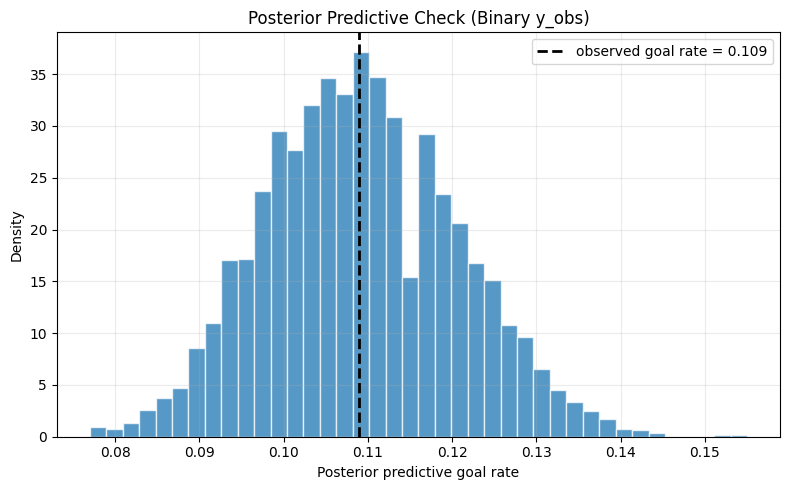

In [61]:
# Binary PPC check without sample_dims issues
import numpy as np
import matplotlib.pyplot as plt

idata_pps_full = pps_full if hasattr(pps_full, "posterior_predictive") else pps_full.to_inference_data()

y_obs = np.asarray(idata_pps_full["observed_data"].ds["y_obs"]).astype(int).ravel()
y_rep = np.asarray(idata_pps_full["posterior_predictive"].ds["y_obs"]).reshape(-1, y_obs.size)

pred_goal_rate = y_rep.mean(axis=1)
obs_goal_rate = y_obs.mean()

plt.figure(figsize=(8, 5))
plt.hist(pred_goal_rate, bins=40, density=True, alpha=0.75, color="tab:blue", edgecolor="white")
plt.axvline(obs_goal_rate, color="black", linestyle="--", linewidth=2, label=f"observed goal rate = {obs_goal_rate:.3f}")
plt.xlabel("Posterior predictive goal rate")
plt.ylabel("Density")
plt.title("Posterior Predictive Check (Binary y_obs)")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

In [21]:
df["xg_mean"] = pps_full["posterior_predictive"]["p"].mean(("chain", "draw"))
df["xg_std"] = pps_full["posterior_predictive"]["p"].std(("chain", "draw"))

df["xg_mean_only_xy"] = pps_xy["posterior_predictive"]["p"].mean(("chain", "draw"))
df["xg_std_only_xy"] = pps_xy["posterior_predictive"]["p"].std(("chain", "draw"))

In [23]:
from sklearn.metrics import roc_auc_score, brier_score_loss, log_loss
log_loss(df["is_goal"], df["xg_mean"])

0.23416146400700846

In [24]:
log_loss(df["is_goal"], df["xg_mean_only_xy"])

0.31956390183364347

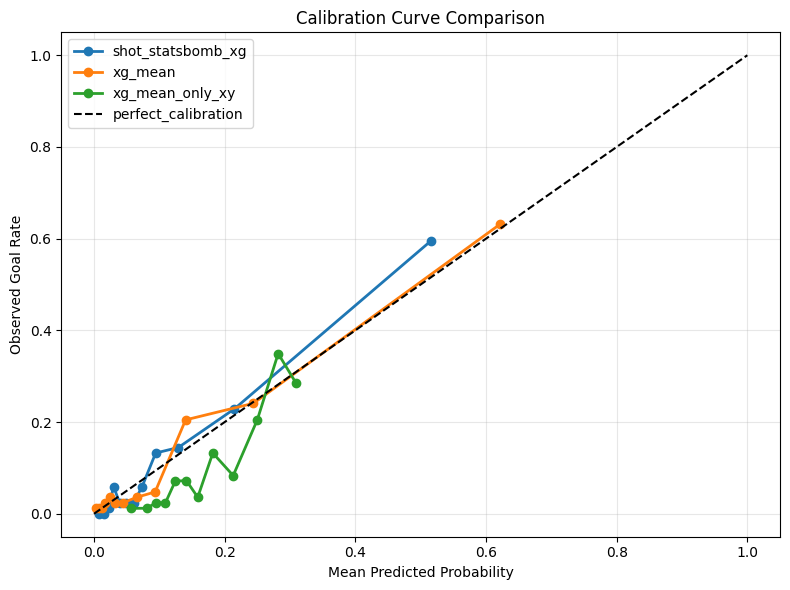

,model,roc_auc,log_loss,brier_score
0,xg_mean,0.872502,0.234161,0.066571
1,shot_statsbomb_xg,0.862437,0.242443,0.069766
2,xg_mean_only_xy,0.777711,0.319564,0.091152


In [27]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import roc_auc_score, log_loss, brier_score_loss
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

required_cols = ["is_goal", "shot_statsbomb_xg", "xg_mean", "xg_mean_only_xy"]
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns for calibration/metrics: {missing_cols}")

eval_df = df[required_cols].dropna().copy()
eval_df["is_goal"] = eval_df["is_goal"].astype(int)

pred_cols = ["shot_statsbomb_xg", "xg_mean", "xg_mean_only_xy"]
for c in pred_cols:
    eval_df[c] = np.clip(eval_df[c].astype(float), 1e-6, 1 - 1e-6)

# Calibration plot: all three on same chart
plt.figure(figsize=(8, 6))
for c in pred_cols:
    frac_pos, mean_pred = calibration_curve(eval_df["is_goal"], eval_df[c], n_bins=12, strategy="quantile")
    plt.plot(mean_pred, frac_pos, marker="o", linewidth=2, label=c)

plt.plot([0, 1], [0, 1], "k--", linewidth=1.5, label="perfect_calibration")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Goal Rate")
plt.title("Calibration Curve Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Metrics table: ROC AUC, log loss, brier score
metrics_rows = []
for c in pred_cols:
    metrics_rows.append({
        "model": c,
        "roc_auc": roc_auc_score(eval_df["is_goal"], eval_df[c]),
        "log_loss": log_loss(eval_df["is_goal"], eval_df[c]),
        "brier_score": brier_score_loss(eval_df["is_goal"], eval_df[c]),
    })

metrics_df = pd.DataFrame(metrics_rows).sort_values("roc_auc", ascending=False).reset_index(drop=True)
metrics_df

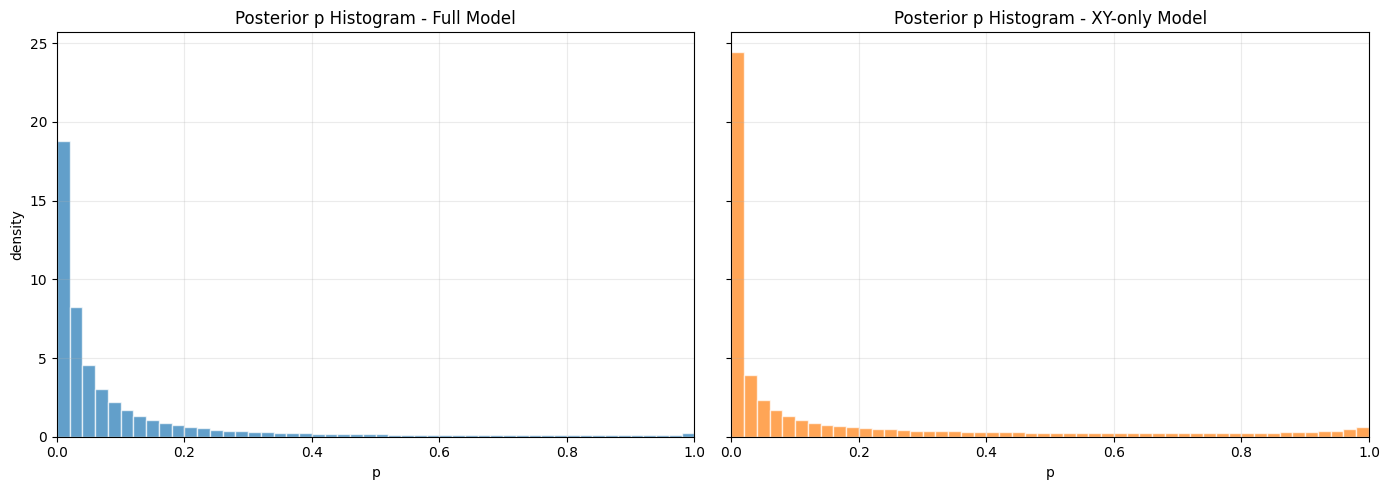

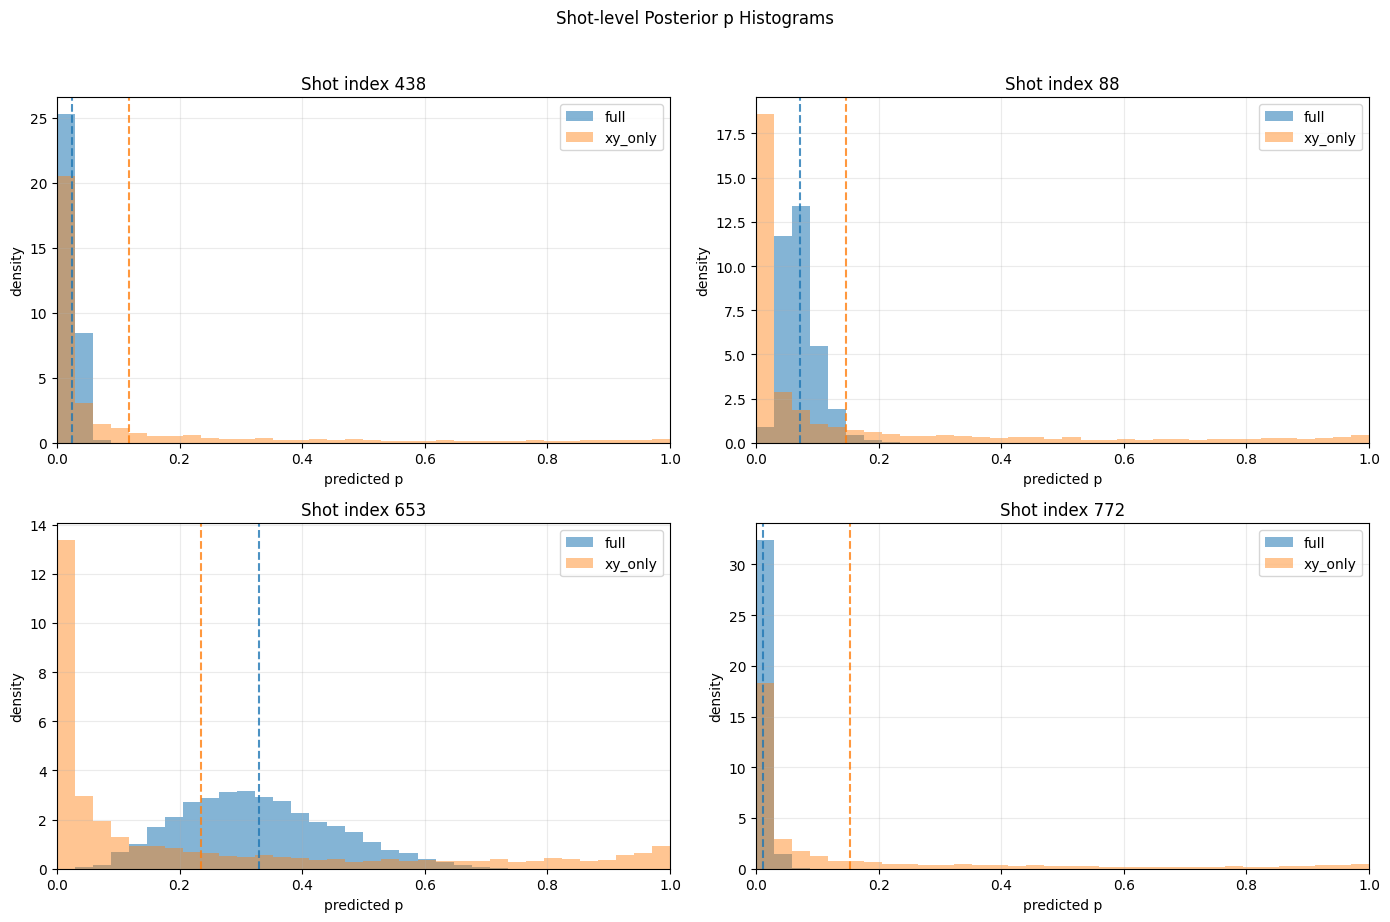

In [29]:
# Histogram-only view of posterior p values (no std plots)
import numpy as np
import matplotlib.pyplot as plt

p_full = np.asarray(pps_full["posterior_predictive"]["p"]).reshape(-1, len(df))
p_xy = np.asarray(pps_xy["posterior_predictive"]["p"]).reshape(-1, len(df))

# Overall posterior p distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

axes[0].hist(p_full.ravel(), bins=50, density=True, alpha=0.7, color="tab:blue", edgecolor="white")
axes[0].set_title("Posterior p Histogram - Full Model")
axes[0].set_xlabel("p")
axes[0].set_ylabel("density")
axes[0].set_xlim(0, 1)
axes[0].grid(alpha=0.25)

axes[1].hist(p_xy.ravel(), bins=50, density=True, alpha=0.7, color="tab:orange", edgecolor="white")
axes[1].set_title("Posterior p Histogram - XY-only Model")
axes[1].set_xlabel("p")
axes[1].set_xlim(0, 1)
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

# Shot-level posterior p histograms for random shots
rng = np.random.default_rng(42)
idx = rng.choice(len(df), size=min(4, len(df)), replace=False)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.ravel()
for k, shot_idx in enumerate(idx):
    ax = axes[k]
    vals_full = p_full[:, shot_idx]
    vals_xy = p_xy[:, shot_idx]

    bins = np.linspace(0, 1, 35)
    ax.hist(vals_full, bins=bins, density=True, alpha=0.55, label="full", color="tab:blue")
    ax.hist(vals_xy, bins=bins, density=True, alpha=0.45, label="xy_only", color="tab:orange")

    ax.axvline(vals_full.mean(), linestyle="--", alpha=0.8, color="tab:blue")
    ax.axvline(vals_xy.mean(), linestyle="--", alpha=0.8, color="tab:orange")
    ax.set_xlim(0, 1)
    ax.set_title(f"Shot index {shot_idx}")
    ax.set_xlabel("predicted p")
    ax.set_ylabel("density")
    ax.grid(alpha=0.25)
    ax.legend()

plt.suptitle("Shot-level Posterior p Histograms", y=1.02)
plt.tight_layout()
plt.show()

In [12]:
model_inputs = bayesian_xg._preprocess(df_train, target_col="is_goal")

In [14]:
model_inputs["goalkeeper_shooter_distance"]

array([ 0.9486833 , 21.78921752, 10.96357606, ...,         nan,
       13.80579588, 18.79627623], shape=(32000,))

In [11]:
bayesian_xg.fit(df_test, target_col="is_goal")

NotImplementedError: Masked arrays or arrays with `nan` entries are not supported. Pass them directly to `observed` if you want to trigger auto-imputation

In [ ]:
# Enforce split equation form everywhere using per-feature missing latents only

def _build_model_split(self, model_inputs: dict = None):
    if model_inputs is None:
        model_inputs = self._model_inputs

    with pm.Model() as model:
        # --- Continuous Values ---
        shot_angle = pm.Data("shot_angle", np.asarray(model_inputs["shot_angle"]))
        shot_distance = pm.Data("shot_distance", np.asarray(model_inputs["shot_distance"]))
        shot_dist_ang = pm.Data("shot_distance_angle", np.asarray(model_inputs["shot_distance_angle"]))
        gk_dist = pm.Data("goalkeeper_shooter_distance", np.asarray(model_inputs["goalkeeper_shooter_distance"]))
        gk_angle = pm.Data("goalkeeper_shooter_angle", np.asarray(model_inputs["goalkeeper_shooter_angle"]))
        gk_dist_ang = pm.Data("goalkeeper_shooter_distance_angle", np.asarray(model_inputs["goalkeeper_shooter_distance_angle"]))
        players_bet = pm.Data("players_between", np.asarray(model_inputs["players_between_shooter_and_goal"]))

        # --- Binary Values ---
        shot_ft = pm.Data("shot_first_time", np.asarray(model_inputs["shot_first_time"]))
        shot_fd = pm.Data("shot_follows_dribble", np.asarray(model_inputs["shot_follows_dribble"]))
        under_p = pm.Data("under_pressure", np.asarray(model_inputs["under_pressure"]))
        open_g = pm.Data("is_open_goal", np.asarray(model_inputs["is_open_goal"]))

        # --- Continuous Missing Masks ---
        shot_angle_m = pm.Data("shot_angle_missing", np.asarray(model_inputs["shot_angle_missing"]))
        shot_dist_m = pm.Data("shot_distance_missing", np.asarray(model_inputs["shot_distance_missing"]))
        shot_dist_ang_m = pm.Data("shot_distance_angle_missing", np.asarray(model_inputs["shot_distance_angle_missing"]))
        gk_dist_m = pm.Data("gk_dist_missing", np.asarray(model_inputs["goalkeeper_shooter_distance_missing"]))
        gk_angle_m = pm.Data("gk_angle_missing", np.asarray(model_inputs["goalkeeper_shooter_angle_missing"]))
        gk_dist_ang_m = pm.Data("gk_dist_angle_missing", np.asarray(model_inputs["goalkeeper_shooter_distance_angle_missing"]))
        players_bet_m = pm.Data("players_between_missing", np.asarray(model_inputs["players_between_shooter_and_goal_missing"]))

        # --- Binary Missing Masks ---
        ft_m = pm.Data("shot_first_time_missing", np.asarray(model_inputs["shot_first_time_missing"]))
        fd_m = pm.Data("shot_follows_dribble_missing", np.asarray(model_inputs["shot_follows_dribble_missing"]))
        up_m = pm.Data("under_pressure_missing", np.asarray(model_inputs["under_pressure_missing"]))
        oog_m = pm.Data("is_open_goal_missing", np.asarray(model_inputs["is_open_goal_missing"]))

        # --- Cat indices ---
        sbp_idx = pm.Data("shot_body_part_idx", np.asarray(model_inputs["cat_idx"]["shot_body_part"]))
        st_idx = pm.Data("shot_technique_idx", np.asarray(model_inputs["cat_idx"]["shot_technique"]))
        at_idx = pm.Data("assist_type_idx", np.asarray(model_inputs["cat_idx"]["assist_type"]))
        ah_idx = pm.Data("assist_height_idx", np.asarray(model_inputs["cat_idx"]["assist_height"]))
        pp_idx = pm.Data("play_pattern_idx", np.asarray(model_inputs["cat_idx"]["play_pattern"]))

        sbp_miss = pm.Data("shot_body_part_missing_data", np.asarray(model_inputs["shot_body_part_missing"]))
        st_miss = pm.Data("shot_technique_missing_data", np.asarray(model_inputs["shot_technique_missing"]))
        at_miss = pm.Data("assist_type_missing_data", np.asarray(model_inputs["assist_type_missing"]))
        ah_miss = pm.Data("assist_height_missing_data", np.asarray(model_inputs["assist_height_missing"]))
        pp_miss = pm.Data("play_pattern_missing_data", np.asarray(model_inputs["play_pattern_missing"]))

        # --- Pressure ---
        dp_idx = pm.Data("pressure_idx", np.asarray(model_inputs["pressure_idx"]))
        dp_m = pm.Data("pressure_missing", np.asarray(model_inputs["pressure_missing"]))

        y = pm.Data("y", np.asarray(model_inputs["y"]))

        # Priors
        alpha = pm.Normal("alpha", mu=-2.2, sigma=1)

        # Continuous betas
        b_shot_angle = pm.Normal("beta_shot_angle", 0, 1)
        b_shot_dist = pm.Normal("beta_shot_distance", 0, 1)
        b_shot_dist_angle = pm.Normal("beta_shot_distance_angle", 0, 1)
        b_gk_dist = pm.Normal("beta_gk_dist", 0, 1)
        b_gk_angle = pm.Normal("beta_gk_angle", 0, 1)
        b_gk_dist_angle = pm.Normal("beta_gk_dist_angle", 0, 1)
        b_players = pm.Normal("beta_players_between", 0, 1)

        # Binary betas
        b_ft = pm.Normal("beta_shot_first_time", 0, 1)
        b_fd = pm.Normal("beta_shot_follows_dribble", 0, 1)
        b_up = pm.Normal("beta_under_pressure", 0, 1)
        b_og = pm.Normal("beta_is_open_goal", 0, 1)

        # Missing-value latent feature realizations x_k^mis (heavy-tailed where appropriate)
        shot_angle_mis_lat = pm.StudentT("shot_angle_mis_lat", nu=3, mu=0, sigma=1)
        shot_dist_mis_lat = pm.StudentT("shot_dist_mis_lat", nu=3, mu=0, sigma=1)
        shot_dist_ang_mis_lat = pm.StudentT("shot_dist_ang_mis_lat", nu=3, mu=0, sigma=1)
        gk_dist_mis_lat = pm.StudentT("gk_dist_mis_lat", nu=3, mu=0, sigma=1)
        gk_angle_mis_lat = pm.StudentT("gk_angle_mis_lat", nu=3, mu=0, sigma=1)
        gk_dist_ang_mis_lat = pm.StudentT("gk_dist_ang_mis_lat", nu=3, mu=0, sigma=1)
        players_mis_lat = pm.StudentT("players_mis_lat", nu=3, mu=0, sigma=1)

        shot_ft_mis_lat = pm.Beta("shot_ft_mis_lat", 2, 2)
        shot_fd_mis_lat = pm.Beta("shot_fd_mis_lat", 2, 2)
        under_p_mis_lat = pm.Beta("under_p_mis_lat", 2, 2)
        open_g_mis_lat = pm.Beta("open_g_mis_lat", 2, 2)

        # Categorical embeddings + explicit missing effects
        sbp_emb = pm.Normal("shot_body_part_emb", 0, 2, shape=model_inputs["n_levels"]["shot_body_part"])
        st_emb = pm.Normal("shot_technique_emb", 0, 2, shape=model_inputs["n_levels"]["shot_technique"])
        at_emb = pm.Normal("assist_type_emb", 0, 2, shape=model_inputs["n_levels"]["assist_type"])
        ah_emb = pm.Normal("assist_height_emb", 0, 2, shape=model_inputs["n_levels"]["assist_height"])
        pp_emb = pm.Normal("play_pattern_emb", 0, 2, shape=model_inputs["n_levels"]["play_pattern"])

        sbp_mis_eff = pm.Normal("shot_body_part_missing_effect", 0, 1)
        st_mis_eff = pm.Normal("shot_technique_missing_effect", 0, 1)
        at_mis_eff = pm.Normal("assist_type_missing_effect", 0, 1)
        ah_mis_eff = pm.Normal("assist_height_missing_effect", 0, 1)
        pp_mis_eff = pm.Normal("play_pattern_missing_effect", 0, 1)

        # Pressure effects
        b_pressure = pm.Normal("beta_pressure_levels", 0, 1, shape=model_inputs["n_pressure_levels"])
        b_pressure_m = pm.Normal("beta_pressure_missing", 0, 1)

        # -------------------------
        # Split equation: observed + missing
        # -------------------------
        eta_obs = 0
        eta_mis = 0

        # continuous
        eta_obs += b_shot_angle * (shot_angle * (1 - shot_angle_m))
        eta_mis += b_shot_angle * (shot_angle_mis_lat * shot_angle_m)

        eta_obs += b_shot_dist * (shot_distance * (1 - shot_dist_m))
        eta_mis += b_shot_dist * (shot_dist_mis_lat * shot_dist_m)

        eta_obs += b_shot_dist_angle * (shot_dist_ang * (1 - shot_dist_ang_m))
        eta_mis += b_shot_dist_angle * (shot_dist_ang_mis_lat * shot_dist_ang_m)

        eta_obs += b_gk_dist * (gk_dist * (1 - gk_dist_m))
        eta_mis += b_gk_dist * (gk_dist_mis_lat * gk_dist_m)

        eta_obs += b_gk_angle * (gk_angle * (1 - gk_angle_m))
        eta_mis += b_gk_angle * (gk_angle_mis_lat * gk_angle_m)

        eta_obs += b_gk_dist_angle * (gk_dist_ang * (1 - gk_dist_ang_m))
        eta_mis += b_gk_dist_angle * (gk_dist_ang_mis_lat * gk_dist_ang_m)

        eta_obs += b_players * (players_bet * (1 - players_bet_m))
        eta_mis += b_players * (players_mis_lat * players_bet_m)

        # binary
        eta_obs += b_ft * (shot_ft * (1 - ft_m))
        eta_mis += b_ft * (shot_ft_mis_lat * ft_m)

        eta_obs += b_fd * (shot_fd * (1 - fd_m))
        eta_mis += b_fd * (shot_fd_mis_lat * fd_m)

        eta_obs += b_up * (under_p * (1 - up_m))
        eta_mis += b_up * (under_p_mis_lat * up_m)

        eta_obs += b_og * (open_g * (1 - oog_m))
        eta_mis += b_og * (open_g_mis_lat * oog_m)

        # pressure and categorical split terms
        eta_obs += b_pressure[dp_idx] * (1 - dp_m)
        eta_mis += b_pressure_m * dp_m

        eta_obs += sbp_emb[sbp_idx] * (1 - sbp_miss)
        eta_mis += sbp_mis_eff * sbp_miss

        eta_obs += st_emb[st_idx] * (1 - st_miss)
        eta_mis += st_mis_eff * st_miss

        eta_obs += at_emb[at_idx] * (1 - at_miss)
        eta_mis += at_mis_eff * at_miss

        eta_obs += ah_emb[ah_idx] * (1 - ah_miss)
        eta_mis += ah_mis_eff * ah_miss

        eta_obs += pp_emb[pp_idx] * (1 - pp_miss)
        eta_mis += pp_mis_eff * pp_miss

        eta = alpha + eta_obs + eta_mis

        p = pm.Deterministic("p", pm.math.sigmoid(eta))
        pm.Bernoulli("y_obs", p=p, observed=y)

    return model


def _posterior_mean_xg_split(self, df: pd.DataFrame, target_col: str, posterior):
    def scalar(name):
        return np.asarray(posterior[name].values).reshape(-1)

    def emb(name):
        arr = np.asarray(posterior[name].values)
        return arr.reshape(-1, *arr.shape[2:])

    inputs = self._preprocess(df, target_col=target_col, fit_scaler=False)
    S = scalar("beta_shot_angle").shape[0]
    N = inputs["shot_angle"].shape[0]

    def b(arr):
        return arr.reshape(S, 1)

    def f(vec):
        return vec.reshape(1, N)

    eta_obs = np.zeros((S, N), dtype=float)
    eta_mis = np.zeros((S, N), dtype=float)

    # continuous observed + missing
    eta_obs += b(scalar("beta_shot_angle")) * f(inputs["shot_angle"] * (1 - inputs["shot_angle_missing"]))
    eta_mis += b(scalar("beta_shot_angle")) * f(scalar("shot_angle_mis_lat").mean() * inputs["shot_angle_missing"])

    eta_obs += b(scalar("beta_shot_distance")) * f(inputs["shot_distance"] * (1 - inputs["shot_distance_missing"]))
    eta_mis += b(scalar("beta_shot_distance")) * f(scalar("shot_dist_mis_lat").mean() * inputs["shot_distance_missing"])

    eta_obs += b(scalar("beta_shot_distance_angle")) * f(inputs["shot_distance_angle"] * (1 - inputs["shot_distance_angle_missing"]))
    eta_mis += b(scalar("beta_shot_distance_angle")) * f(scalar("shot_dist_ang_mis_lat").mean() * inputs["shot_distance_angle_missing"])

    eta_obs += b(scalar("beta_gk_dist")) * f(inputs["goalkeeper_shooter_distance"] * (1 - inputs["goalkeeper_shooter_distance_missing"]))
    eta_mis += b(scalar("beta_gk_dist")) * f(scalar("gk_dist_mis_lat").mean() * inputs["goalkeeper_shooter_distance_missing"])

    eta_obs += b(scalar("beta_gk_angle")) * f(inputs["goalkeeper_shooter_angle"] * (1 - inputs["goalkeeper_shooter_angle_missing"]))
    eta_mis += b(scalar("beta_gk_angle")) * f(scalar("gk_angle_mis_lat").mean() * inputs["goalkeeper_shooter_angle_missing"])

    eta_obs += b(scalar("beta_gk_dist_angle")) * f(inputs["goalkeeper_shooter_distance_angle"] * (1 - inputs["goalkeeper_shooter_distance_angle_missing"]))
    eta_mis += b(scalar("beta_gk_dist_angle")) * f(scalar("gk_dist_ang_mis_lat").mean() * inputs["goalkeeper_shooter_distance_angle_missing"])

    eta_obs += b(scalar("beta_players_between")) * f(inputs["players_between_shooter_and_goal"] * (1 - inputs["players_between_shooter_and_goal_missing"]))
    eta_mis += b(scalar("beta_players_between")) * f(scalar("players_mis_lat").mean() * inputs["players_between_shooter_and_goal_missing"])

    # binary observed + missing
    eta_obs += b(scalar("beta_shot_first_time")) * f(inputs["shot_first_time"] * (1 - inputs["shot_first_time_missing"]))
    eta_mis += b(scalar("beta_shot_first_time")) * f(scalar("shot_ft_mis_lat").mean() * inputs["shot_first_time_missing"])

    eta_obs += b(scalar("beta_shot_follows_dribble")) * f(inputs["shot_follows_dribble"] * (1 - inputs["shot_follows_dribble_missing"]))
    eta_mis += b(scalar("beta_shot_follows_dribble")) * f(scalar("shot_fd_mis_lat").mean() * inputs["shot_follows_dribble_missing"])

    eta_obs += b(scalar("beta_under_pressure")) * f(inputs["under_pressure"] * (1 - inputs["under_pressure_missing"]))
    eta_mis += b(scalar("beta_under_pressure")) * f(scalar("under_p_mis_lat").mean() * inputs["under_pressure_missing"])

    eta_obs += b(scalar("beta_is_open_goal")) * f(inputs["is_open_goal"] * (1 - inputs["is_open_goal_missing"]))
    eta_mis += b(scalar("beta_is_open_goal")) * f(scalar("open_g_mis_lat").mean() * inputs["is_open_goal_missing"])

    # pressure
    b_pres = emb("beta_pressure_levels")
    eta_obs += b_pres[:, inputs["pressure_idx"]] * f(1 - inputs["pressure_missing"])
    eta_mis += b(scalar("beta_pressure_missing")) * f(inputs["pressure_missing"])

    # categorical observed + missing
    for col, emb_name, mis_eff_name in [
        ("shot_body_part", "shot_body_part_emb", "shot_body_part_missing_effect"),
        ("shot_technique", "shot_technique_emb", "shot_technique_missing_effect"),
        ("assist_type", "assist_type_emb", "assist_type_missing_effect"),
        ("assist_height", "assist_height_emb", "assist_height_missing_effect"),
        ("play_pattern", "play_pattern_emb", "play_pattern_missing_effect"),
    ]:
        e = emb(emb_name)
        idx = inputs["cat_idx"][col]
        miss = inputs["cat_missing"][col]
        eta_obs += e[:, idx] * f(1 - miss)
        eta_mis += b(scalar(mis_eff_name)) * f(miss)

    eta = b(scalar("alpha")) + eta_obs + eta_mis
    p = sigmoid(eta)
    return p.mean(axis=0), p.std(axis=0)


# Override class methods so the model uses the split equation everywhere
BayesianXg._build_model = _build_model_split
BayesianXg._posterior_mean_xg = _posterior_mean_xg_split

print("BayesianXg updated with split-form eta and per-feature missing latents only.")

BayesianXg updated with split-form eta and missingness tail inflation.
